===== Aperçu des données =====
   Age  Gender      Height     Weight        BMI  PhysicalActivityLevel  \
0   56    Male  173.575262  71.982051  23.891783                      4   
1   69    Male  164.127306  89.959256  33.395209                      2   
2   46  Female  168.072202  72.930629  25.817737                      4   
3   32    Male  168.459633  84.886912  29.912247                      3   
4   60    Male  183.568568  69.038945  20.487903                      3   

  ObesityCategory  
0   Normal weight  
1           Obese  
2      Overweight  
3      Overweight  
4   Normal weight  

===== Dimensions de la base =====
Nombre de lignes : 1000
Nombre de colonnes : 7

===== Informations sur les variables =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1000 non-null   int64  
 1   Gender

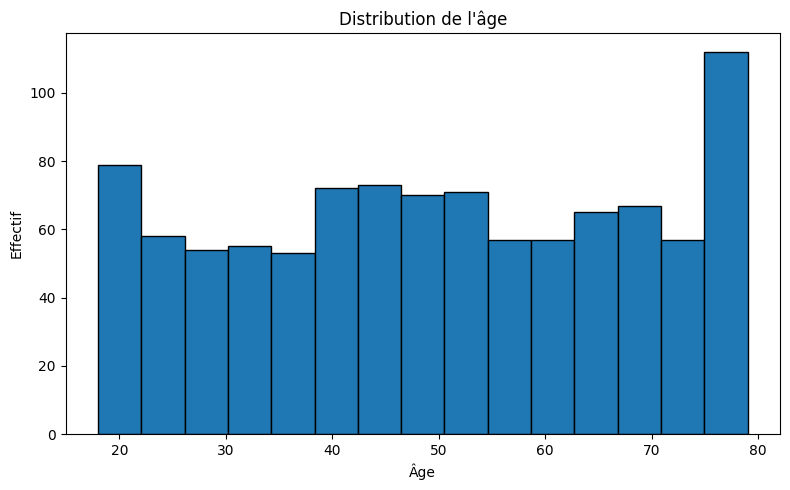

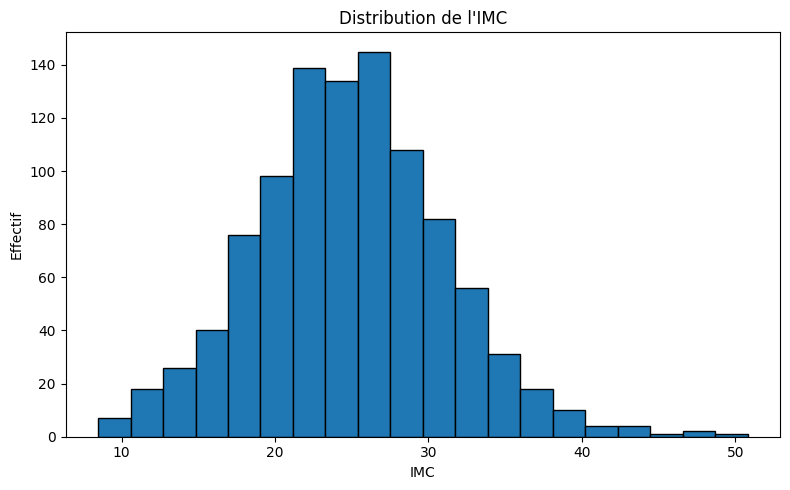

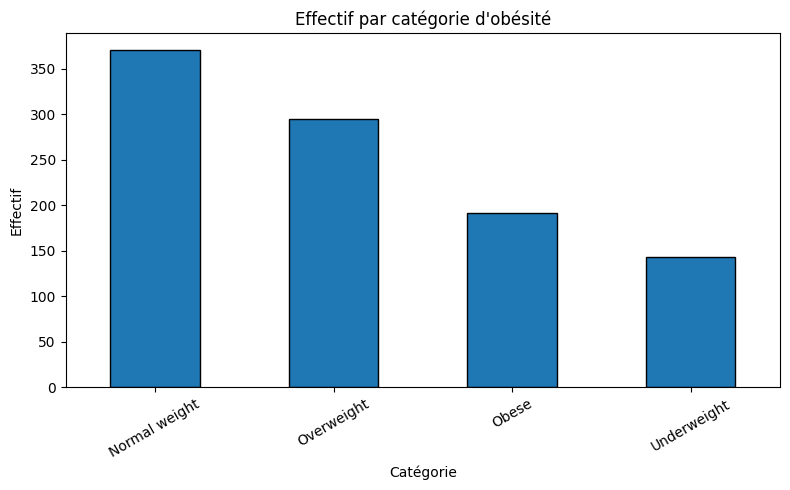

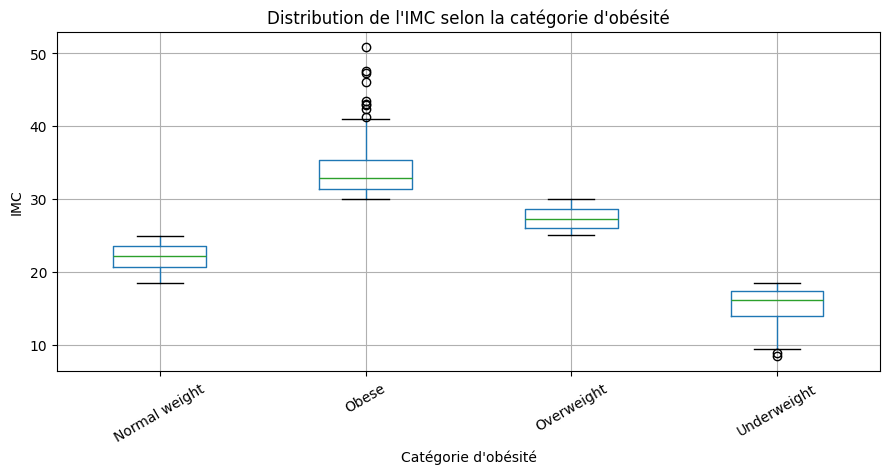

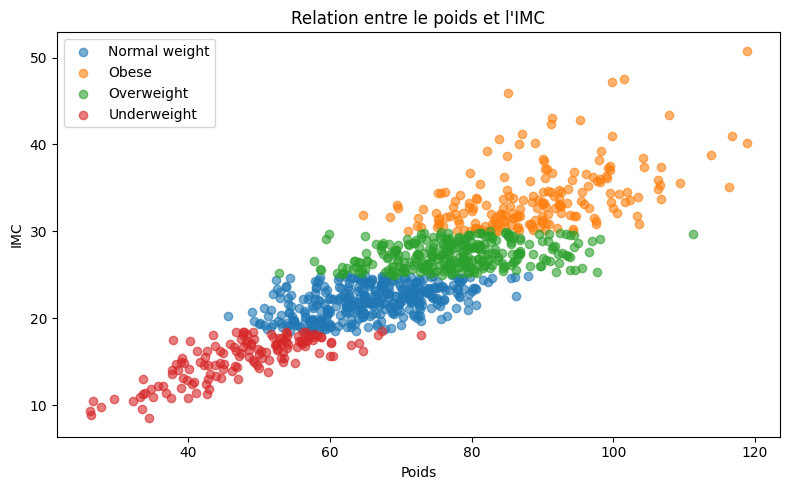


Analyse terminée.
Les fichiers moyennes_par_categorie.csv et matrice_correlations.csv ont été créés.


In [ ]:
# ============================================================
# Analyse statistique descriptive du jeu obesity_data.csv
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Chargement des données
# ------------------------------------------------------------

# Adapter le chemin si nécessaire
fichier = "obesity_data.csv"

df = pd.read_csv(fichier)

print("===== Aperçu des données =====")
print(df.head())

# ------------------------------------------------------------
# 2. Dimensions et informations générales
# ------------------------------------------------------------

print("\n===== Dimensions de la base =====")
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

print("\n===== Informations sur les variables =====")
print(df.info())

print("\n===== Noms des colonnes =====")
print(df.columns.tolist())

# ------------------------------------------------------------
# 3. Vérification des valeurs manquantes
# ------------------------------------------------------------

print("\n===== Valeurs manquantes =====")
missing_values = df.isnull().sum()
print(missing_values)

print("\n===== Pourcentage de valeurs manquantes =====")
missing_percent = df.isnull().mean() * 100
print(missing_percent.round(2))

# ------------------------------------------------------------
# 4. Vérification des doublons
# ------------------------------------------------------------

print("\n===== Doublons =====")
print("Nombre de doublons :", df.duplicated().sum())

# ------------------------------------------------------------
# 5. Types des variables
# ------------------------------------------------------------

print("\n===== Types des variables =====")
print(df.dtypes)

# ------------------------------------------------------------
# 6. Statistiques descriptives des variables numériques
# ------------------------------------------------------------

print("\n===== Statistiques descriptives numériques =====")
print(df.describe().round(2))

# Statistiques supplémentaires
variables_numeriques = [
    "Age",
    "Height",
    "Weight",
    "BMI",
    "PhysicalActivityLevel"
]

print("\n===== Statistiques détaillées =====")
for variable in variables_numeriques:
    if variable in df.columns:
        print(f"\n--- {variable} ---")
        print("Moyenne :", round(df[variable].mean(), 2))
        print("Médiane :", round(df[variable].median(), 2))
        print("Écart-type :", round(df[variable].std(), 2))
        print("Minimum :", round(df[variable].min(), 2))
        print("Maximum :", round(df[variable].max(), 2))

# ------------------------------------------------------------
# 7. Analyse des variables catégorielles
# ------------------------------------------------------------

variables_categorielles = [
    "Gender",
    "ObesityCategory"
]

for variable in variables_categorielles:
    if variable in df.columns:
        print(f"\n===== Distribution de {variable} =====")
        print(df[variable].value_counts())

        print(f"\nPourcentage des modalités de {variable} :")
        print((df[variable].value_counts(normalize=True) * 100).round(2))

# ------------------------------------------------------------
# 8. Moyennes selon la catégorie d'obésité
# ------------------------------------------------------------

print("\n===== Moyennes selon la catégorie d'obésité =====")

moyennes_par_categorie = df.groupby("ObesityCategory")[
    ["Age", "Height", "Weight", "BMI", "PhysicalActivityLevel"]
].mean()

print(moyennes_par_categorie.round(2))

# Médianes selon la catégorie
print("\n===== Médianes selon la catégorie d'obésité =====")

medianes_par_categorie = df.groupby("ObesityCategory")[
    ["Age", "Height", "Weight", "BMI", "PhysicalActivityLevel"]
].median()

print(medianes_par_categorie.round(2))

# ------------------------------------------------------------
# 9. Tableau croisé entre le sexe et la catégorie d'obésité
# ------------------------------------------------------------

print("\n===== Tableau croisé Gender / ObesityCategory =====")

tableau_croise = pd.crosstab(
    df["Gender"],
    df["ObesityCategory"]
)

print(tableau_croise)

print("\n===== Pourcentages par sexe =====")

tableau_pourcentage = pd.crosstab(
    df["Gender"],
    df["ObesityCategory"],
    normalize="index"
) * 100

print(tableau_pourcentage.round(2))

# ------------------------------------------------------------
# 10. Corrélations entre les variables numériques
# ------------------------------------------------------------

print("\n===== Matrice de corrélation =====")

correlations = df[variables_numeriques].corr()
print(correlations.round(2))

# ------------------------------------------------------------
# 11. Détection simple des valeurs aberrantes
#    Méthode de l'écart interquartile, IQR
# ------------------------------------------------------------

print("\n===== Valeurs aberrantes =====")

for variable in variables_numeriques:
    if variable in df.columns:

        Q1 = df[variable].quantile(0.25)
        Q3 = df[variable].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferieure = Q1 - 1.5 * IQR
        limite_superieure = Q3 + 1.5 * IQR

        valeurs_aberrantes = df[
            (df[variable] < limite_inferieure) |
            (df[variable] > limite_superieure)
        ]

        print(
            variable,
            ":",
            len(valeurs_aberrantes),
            "valeurs potentiellement aberrantes"
        )

# ------------------------------------------------------------
# 12. Visualisations
# ------------------------------------------------------------

# Histogramme de l'âge
plt.figure(figsize=(8, 5))
plt.hist(df["Age"], bins=15, edgecolor="black")
plt.title("Distribution de l'âge")
plt.xlabel("Âge")
plt.ylabel("Effectif")
plt.tight_layout()
plt.show()

# Histogramme de l'IMC
plt.figure(figsize=(8, 5))
plt.hist(df["BMI"], bins=20, edgecolor="black")
plt.title("Distribution de l'IMC")
plt.xlabel("IMC")
plt.ylabel("Effectif")
plt.tight_layout()
plt.show()

# Effectif par catégorie d'obésité
plt.figure(figsize=(8, 5))
df["ObesityCategory"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)
plt.title("Effectif par catégorie d'obésité")
plt.xlabel("Catégorie")
plt.ylabel("Effectif")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Boxplot de l'IMC selon la catégorie
df.boxplot(
    column="BMI",
    by="ObesityCategory",
    figsize=(9, 5)
)

plt.title("Distribution de l'IMC selon la catégorie d'obésité")
plt.suptitle("")
plt.xlabel("Catégorie d'obésité")
plt.ylabel("IMC")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Nuage de points poids / IMC
plt.figure(figsize=(8, 5))

for categorie in df["ObesityCategory"].unique():
    sous_ensemble = df[df["ObesityCategory"] == categorie]

    plt.scatter(
        sous_ensemble["Weight"],
        sous_ensemble["BMI"],
        label=categorie,
        alpha=0.6
    )

plt.title("Relation entre le poids et l'IMC")
plt.xlabel("Poids")
plt.ylabel("IMC")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. Export des résultats
# ------------------------------------------------------------

moyennes_par_categorie.round(2).to_csv(
    "moyennes_par_categorie.csv"
)

correlations.round(2).to_csv(
    "matrice_correlations.csv"
)

print("\nAnalyse terminée.")
print("Les fichiers moyennes_par_categorie.csv et matrice_correlations.csv ont été créés.")


In [ ]:
#===================================================
#Prétraitement de la dataset obesity_data.csv
#===================================================
import pandas as pd

URL = "https://raw.githubusercontent.com/EDJINEDJA/Health-Data-modelling/main/lab1/obesity_data.csv"
df = pd.read_csv(URL)

# 1. Audit de qualité
print("Dimensions :", df.shape)
print(df.dtypes, "\n")
print("Valeurs manquantes :", int(df.isna().sum().sum()))
print("Doublons           :", int(df.duplicated().sum()))
bmi_recalcule = df["Weight"] / (df["Height"] / 100) ** 2
print("Écart max BMI fourni vs recalculé :", float((bmi_recalcule - df["BMI"]).abs().max()))
print("Patients avec IMC < 13 :", int((df["BMI"] < 13).sum()))
print("Patients avec IMC > 45 :", int((df["BMI"] > 45).sum()))

# 2. Encodage
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})
ordre = ["Underweight", "Normal weight", "Overweight", "Obese"]   # ordre clinique, pas alphabétique
df["Obesity_code"] = df["ObesityCategory"].map({c: i for i, c in enumerate(ordre)})
assert df["Obesity_code"].notna().all()

# 3. Jeux de variables (voir Q6)
y = df["Obesity_code"]
jeux_de_variables = {
    "niveau_BMI":          ["BMI"],
    "niveau_taille_poids": ["Height", "Weight"],
    "risque":              ["Age", "Gender", "PhysicalActivityLevel"],
    "toutes":              ["Age", "Gender", "Height", "Weight", "BMI", "PhysicalActivityLevel"],
}
df.head()

Dimensions : (1000, 7)
Age                        int64
Gender                    object
Height                   float64
Weight                   float64
BMI                      float64
PhysicalActivityLevel      int64
ObesityCategory           object
dtype: object 

Valeurs manquantes : 0
Doublons           : 0
Écart max BMI fourni vs recalculé : 2.1316282072803006e-14
Patients avec IMC < 13 : 27
Patients avec IMC > 45 : 4


,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory,Obesity_code
0,56,1,173.575262,71.982051,23.891783,4,Normal weight,1
1,69,1,164.127306,89.959256,33.395209,2,Obese,3
2,46,0,168.072202,72.930629,25.817737,4,Overweight,2
3,32,1,168.459633,84.886912,29.912247,3,Overweight,2
4,60,1,183.568568,69.038945,20.487903,3,Normal weight,1


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             cohen_kappa_score, roc_auc_score)
from IPython.display import display

# ============================================================
# Q8 - Séparation entraînement / test (commune aux deux parties)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42, stratify=y)
print("Entraînement :", len(X_train), "| Test :", len(X_test))

# ============================================================
# Fonction d'évaluation (Q10)
# ============================================================
def evaluer(modele, nom, feats):
    Xt = X_test[feats]
    p = modele.predict(Xt)
    proba = modele.predict_proba(Xt)
    res = {
        "Accuracy test":   accuracy_score(y_test, p),
        "Acc. équilibrée": balanced_accuracy_score(y_test, p),
        "F1 macro":        f1_score(y_test, p, average="macro"),
        "Kappa pondéré":   cohen_kappa_score(y_test, p, weights="quadratic"),
        "AUC (OvR)":       roc_auc_score(y_test, proba, multi_class="ovr", average="macro", labels=[0, 1, 2, 3]),
    }
    print("=" * 10, nom, "=" * 10)
    for k, v in res.items():
        print(f"{k:16s}: {v:.3f}")

    cm = confusion_matrix(y_test, p, labels=[0, 1, 2, 3])
    display(pd.DataFrame(cm, index=[f"Réel {c}" for c in ordre],
                         columns=[f"Préd. {c}" for c in ordre]))

    lignes = []
    for i, c in enumerate(ordre):
        vp = cm[i, i]; fn = cm[i].sum() - vp
        fp = cm[:, i].sum() - vp; vn = cm.sum() - vp - fn - fp
        lignes.append({"Classe": c,
                       "Sensibilité": vp / (vp + fn),
                       "Spécificité": vn / (vn + fp),
                       "VPP": vp / (vp + fp) if vp + fp else np.nan,
                       "VPN": vn / (vn + fn)})
    display(pd.DataFrame(lignes).round(3))
    print(classification_report(y_test, p, target_names=ordre, digits=3, zero_division=0))
    return res

# ============================================================
# Fonction Q9 + Q10 : modèle 1 (CART, Gini, hyperparamètres par défaut)
# ============================================================
def partie(titre, feats):
    print("\n" + "#" * 60 + f"\n# {titre}\n" + "#" * 60)
    # Q9 - construction
    modele = DecisionTreeClassifier(random_state=42)
    modele.fit(X_train[feats], y_train)
    print("Variables  :", feats)
    print("Critère    :", modele.criterion)
    print("Profondeur :", modele.get_depth())
    print("Feuilles   :", modele.get_n_leaves())
    if modele.get_depth() <= 3:                  # arbre lisible en entier
        print(export_text(modele, feature_names=feats))
    # Q10 - évaluation sur le test
    res = evaluer(modele, "Modèle 1 - Gini", feats)
    res.update({"Variables": " + ".join(feats),
                "Profondeur": modele.get_depth(),
                "Feuilles": modele.get_n_leaves(),
                "Accuracy train": modele.score(X_train[feats], y_train)})
    return modele, res

# ============================================================
# PARTIE 1 - Avec le BMI (variable explicative retenue en Q6)
# ============================================================
modele1_p1, res_p1 = partie("PARTIE 1 - Avec le BMI", ["BMI"])

# ============================================================
# PARTIE 2 - Sans le BMI (Height + Weight)
# ============================================================
modele1_p2, res_p2 = partie("PARTIE 2 - Sans le BMI (Height + Weight)", ["Height", "Weight"])

# ============================================================
# Récapitulatif des deux parties
# ============================================================
recap = pd.DataFrame({"Partie 1 - avec BMI": res_p1, "Partie 2 - sans BMI": res_p2})
ordre_lignes = ["Variables", "Profondeur", "Feuilles", "Accuracy train", "Accuracy test",
                "Acc. équilibrée", "F1 macro", "Kappa pondéré", "AUC (OvR)"]
display(recap.loc[ordre_lignes])

Entraînement : 800 | Test : 200

############################################################
# PARTIE 1 - Avec le BMI
############################################################
Variables  : ['BMI']
Critère    : gini
Profondeur : 2
Feuilles   : 4
|--- BMI <= 24.99
|   |--- BMI <= 18.50
|   |   |--- class: 0
|   |--- BMI >  18.50
|   |   |--- class: 1
|--- BMI >  24.99
|   |--- BMI <= 30.00
|   |   |--- class: 2
|   |--- BMI >  30.00
|   |   |--- class: 3

========== Modèle 1 - Gini ==========
Accuracy test   : 1.000
Acc. équilibrée : 1.000
F1 macro        : 1.000
Kappa pondéré   : 1.000
AUC (OvR)       : 1.000


,Préd. Underweight,Préd. Normal weight,Préd. Overweight,Préd. Obese
Réel Underweight,29,0,0,0
Réel Normal weight,0,74,0,0
Réel Overweight,0,0,59,0
Réel Obese,0,0,0,38


,Classe,Sensibilité,Spécificité,VPP,VPN
0,Underweight,1.0,1.0,1.0,1.0
1,Normal weight,1.0,1.0,1.0,1.0
2,Overweight,1.0,1.0,1.0,1.0
3,Obese,1.0,1.0,1.0,1.0


               precision    recall  f1-score   support

  Underweight      1.000     1.000     1.000        29
Normal weight      1.000     1.000     1.000        74
   Overweight      1.000     1.000     1.000        59
        Obese      1.000     1.000     1.000        38

     accuracy                          1.000       200
    macro avg      1.000     1.000     1.000       200
 weighted avg      1.000     1.000     1.000       200


############################################################
# PARTIE 2 - Sans le BMI (Height + Weight)
############################################################
Variables  : ['Height', 'Weight']
Critère    : gini
Profondeur : 9
Feuilles   : 60
========== Modèle 1 - Gini ==========
Accuracy test   : 0.925
Acc. équilibrée : 0.927
F1 macro        : 0.927
Kappa pondéré   : 0.959
AUC (OvR)       : 0.950


,Préd. Underweight,Préd. Normal weight,Préd. Overweight,Préd. Obese
Réel Underweight,28,1,0,0
Réel Normal weight,1,69,4,0
Réel Overweight,0,2,54,3
Réel Obese,0,0,4,34


,Classe,Sensibilité,Spécificité,VPP,VPN
0,Underweight,0.966,0.994,0.966,0.994
1,Normal weight,0.932,0.976,0.958,0.961
2,Overweight,0.915,0.943,0.871,0.964
3,Obese,0.895,0.981,0.919,0.975


               precision    recall  f1-score   support

  Underweight      0.966     0.966     0.966        29
Normal weight      0.958     0.932     0.945        74
   Overweight      0.871     0.915     0.893        59
        Obese      0.919     0.895     0.907        38

     accuracy                          0.925       200
    macro avg      0.928     0.927     0.927       200
 weighted avg      0.926     0.925     0.925       200



,Partie 1 - avec BMI,Partie 2 - sans BMI
Variables,BMI,Height + Weight
Profondeur,2,9
Feuilles,4,60
Accuracy train,1.0,1.0
Accuracy test,1.0,0.925
Acc. équilibrée,1.0,0.926985
F1 macro,1.0,0.927488
Kappa pondéré,1.0,0.958969
AUC (OvR),1.0,0.950378


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ============================================================
# Q11 + Q12 : modèle 2 (même algorithme CART, critère d'entropie)
# ============================================================
def partie_entropie(titre, feats):
    print("\n" + "#" * 60 + f"\n# {titre}\n" + "#" * 60)
    # Q11 - construction
    modele = DecisionTreeClassifier(criterion="entropy", random_state=42)
    modele.fit(X_train[feats], y_train)
    print("Variables  :", feats)
    print("Critère    :", modele.criterion)
    print("Profondeur :", modele.get_depth())
    print("Feuilles   :", modele.get_n_leaves())
    if modele.get_depth() <= 3:
        print(export_text(modele, feature_names=feats))
    # Q12 - évaluation sur le test
    res = evaluer(modele, "Modèle 2 - Entropie", feats)
    res.update({"Variables": " + ".join(feats),
                "Profondeur": modele.get_depth(),
                "Feuilles": modele.get_n_leaves(),
                "Accuracy train": modele.score(X_train[feats], y_train)})
    return modele, res

# ============================================================
# PARTIE 1 - Avec le BMI
# ============================================================
modele2_p1, res2_p1 = partie_entropie("PARTIE 1 - Avec le BMI", ["BMI"])

# ============================================================
# PARTIE 2 - Sans le BMI (Height + Weight)
# ============================================================
modele2_p2, res2_p2 = partie_entropie("PARTIE 2 - Sans le BMI (Height + Weight)", ["Height", "Weight"])

# ============================================================
# Comparaison Gini (Modèle 1) vs Entropie (Modèle 2)
# ============================================================
cv = StratifiedKFold(5, shuffle=True, random_state=42)
def cv_moyenne(critere, feats):
    s = cross_val_score(DecisionTreeClassifier(criterion=critere, random_state=42), df[feats], y, cv=cv)
    return f"{s.mean():.3f} +/- {s.std():.3f}"

colonnes = {
    "P1 BMI - Gini":          (res_p1,  modele1_p1, ["BMI"], "gini"),
    "P1 BMI - Entropie":      (res2_p1, modele2_p1, ["BMI"], "entropy"),
    "P2 sans BMI - Gini":     (res_p2,  modele1_p2, ["Height", "Weight"], "gini"),
    "P2 sans BMI - Entropie": (res2_p2, modele2_p2, ["Height", "Weight"], "entropy"),
}
comparaison = {}
for nom, (res, mod, feats, crit) in colonnes.items():
    comparaison[nom] = {**res, "Validation croisée (5 plis)": cv_moyenne(crit, feats)}

lignes = ["Profondeur", "Feuilles", "Accuracy train", "Accuracy test", "Acc. équilibrée",
          "F1 macro", "Kappa pondéré", "AUC (OvR)", "Validation croisée (5 plis)"]
pd.set_option("display.width", 200)
display(pd.DataFrame(comparaison).loc[lignes])

# Les deux arbres sont-ils identiques ?
for nom, (m1, m2, feats) in {"Partie 1 (BMI)": (modele1_p1, modele2_p1, ["BMI"]),
                             "Partie 2 (sans BMI)": (modele1_p2, modele2_p2, ["Height", "Weight"])}.items():
    identiques = export_text(m1, feature_names=feats) == export_text(m2, feature_names=feats)
    print(f"{nom} : arbres Gini et Entropie identiques ? {identiques}")


############################################################
# PARTIE 1 - Avec le BMI
############################################################
Variables  : ['BMI']
Critère    : entropy
Profondeur : 2
Feuilles   : 4
|--- BMI <= 24.99
|   |--- BMI <= 18.50
|   |   |--- class: 0
|   |--- BMI >  18.50
|   |   |--- class: 1
|--- BMI >  24.99
|   |--- BMI <= 30.00
|   |   |--- class: 2
|   |--- BMI >  30.00
|   |   |--- class: 3

========== Modèle 2 - Entropie ==========
Accuracy test   : 1.000
Acc. équilibrée : 1.000
F1 macro        : 1.000
Kappa pondéré   : 1.000
AUC (OvR)       : 1.000


,Préd. Underweight,Préd. Normal weight,Préd. Overweight,Préd. Obese
Réel Underweight,29,0,0,0
Réel Normal weight,0,74,0,0
Réel Overweight,0,0,59,0
Réel Obese,0,0,0,38


,Classe,Sensibilité,Spécificité,VPP,VPN
0,Underweight,1.0,1.0,1.0,1.0
1,Normal weight,1.0,1.0,1.0,1.0
2,Overweight,1.0,1.0,1.0,1.0
3,Obese,1.0,1.0,1.0,1.0


               precision    recall  f1-score   support

  Underweight      1.000     1.000     1.000        29
Normal weight      1.000     1.000     1.000        74
   Overweight      1.000     1.000     1.000        59
        Obese      1.000     1.000     1.000        38

     accuracy                          1.000       200
    macro avg      1.000     1.000     1.000       200
 weighted avg      1.000     1.000     1.000       200


############################################################
# PARTIE 2 - Sans le BMI (Height + Weight)
############################################################
Variables  : ['Height', 'Weight']
Critère    : entropy
Profondeur : 9
Feuilles   : 59
========== Modèle 2 - Entropie ==========
Accuracy test   : 0.925
Acc. équilibrée : 0.919
F1 macro        : 0.923
Kappa pondéré   : 0.959
AUC (OvR)       : 0.947


,Préd. Underweight,Préd. Normal weight,Préd. Overweight,Préd. Obese
Réel Underweight,27,2,0,0
Réel Normal weight,2,70,2,0
Réel Overweight,0,2,55,2
Réel Obese,0,0,5,33


,Classe,Sensibilité,Spécificité,VPP,VPN
0,Underweight,0.931,0.988,0.931,0.988
1,Normal weight,0.946,0.968,0.946,0.968
2,Overweight,0.932,0.950,0.887,0.971
3,Obese,0.868,0.988,0.943,0.970


               precision    recall  f1-score   support

  Underweight      0.931     0.931     0.931        29
Normal weight      0.946     0.946     0.946        74
   Overweight      0.887     0.932     0.909        59
        Obese      0.943     0.868     0.904        38

     accuracy                          0.925       200
    macro avg      0.927     0.919     0.923       200
 weighted avg      0.926     0.925     0.925       200



,P1 BMI - Gini,P1 BMI - Entropie,P2 sans BMI - Gini,P2 sans BMI - Entropie
Profondeur,2,2,9,9
Feuilles,4,4,60,59
Accuracy train,1.0,1.0,1.0,1.0
Accuracy test,1.0,1.0,0.925,0.925
Acc. équilibrée,1.0,1.0,0.926985,0.919401
F1 macro,1.0,1.0,0.927488,0.922545
Kappa pondéré,1.0,1.0,0.958969,0.958543
AUC (OvR),1.0,1.0,0.950378,0.946521
Validation croisée (5 plis),0.998 +/- 0.002,0.998 +/- 0.002,0.933 +/- 0.017,0.933 +/- 0.021


Partie 1 (BMI) : arbres Gini et Entropie identiques ? True
Partie 2 (sans BMI) : arbres Gini et Entropie identiques ? False


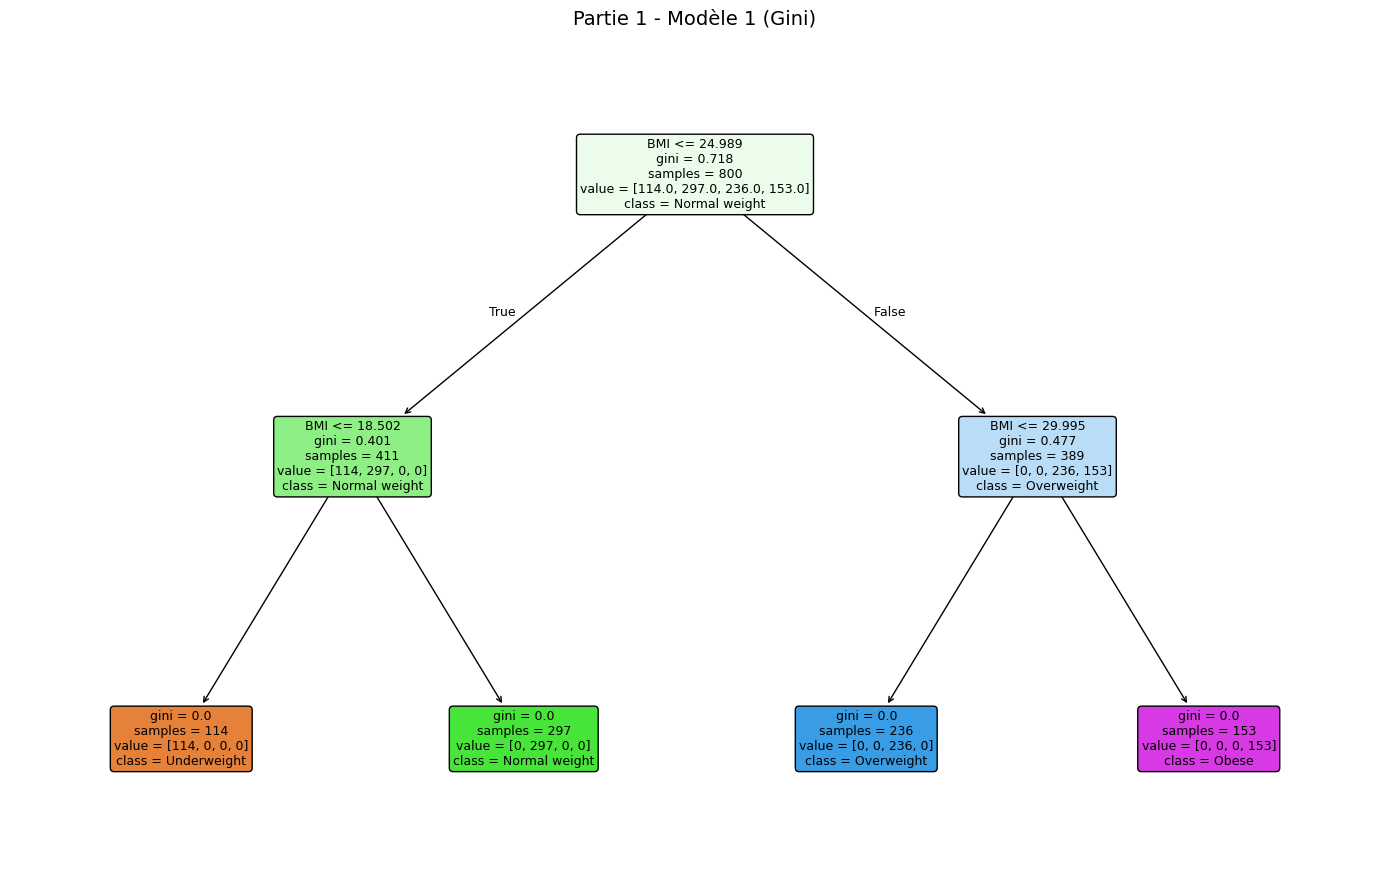

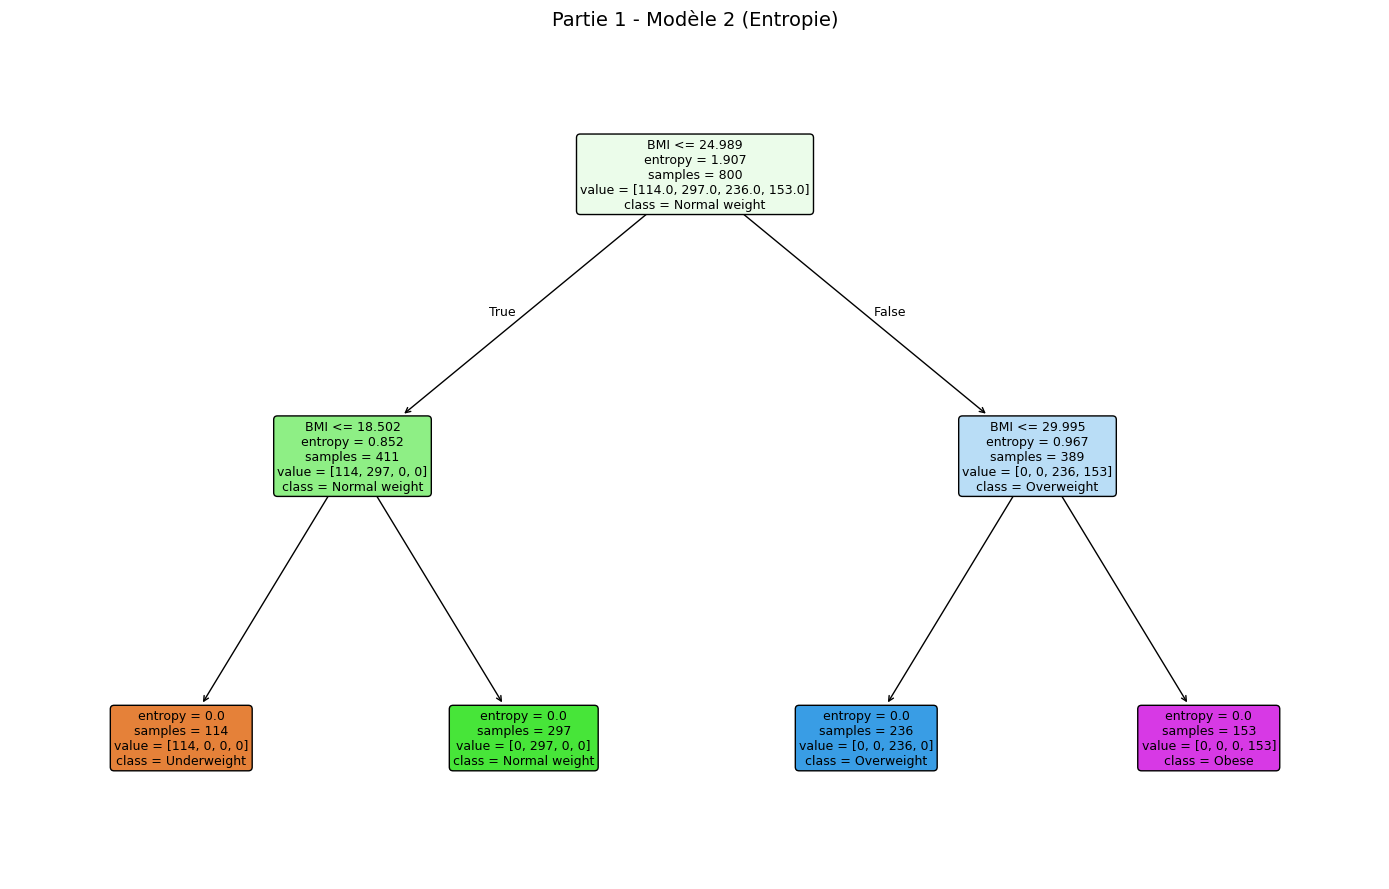

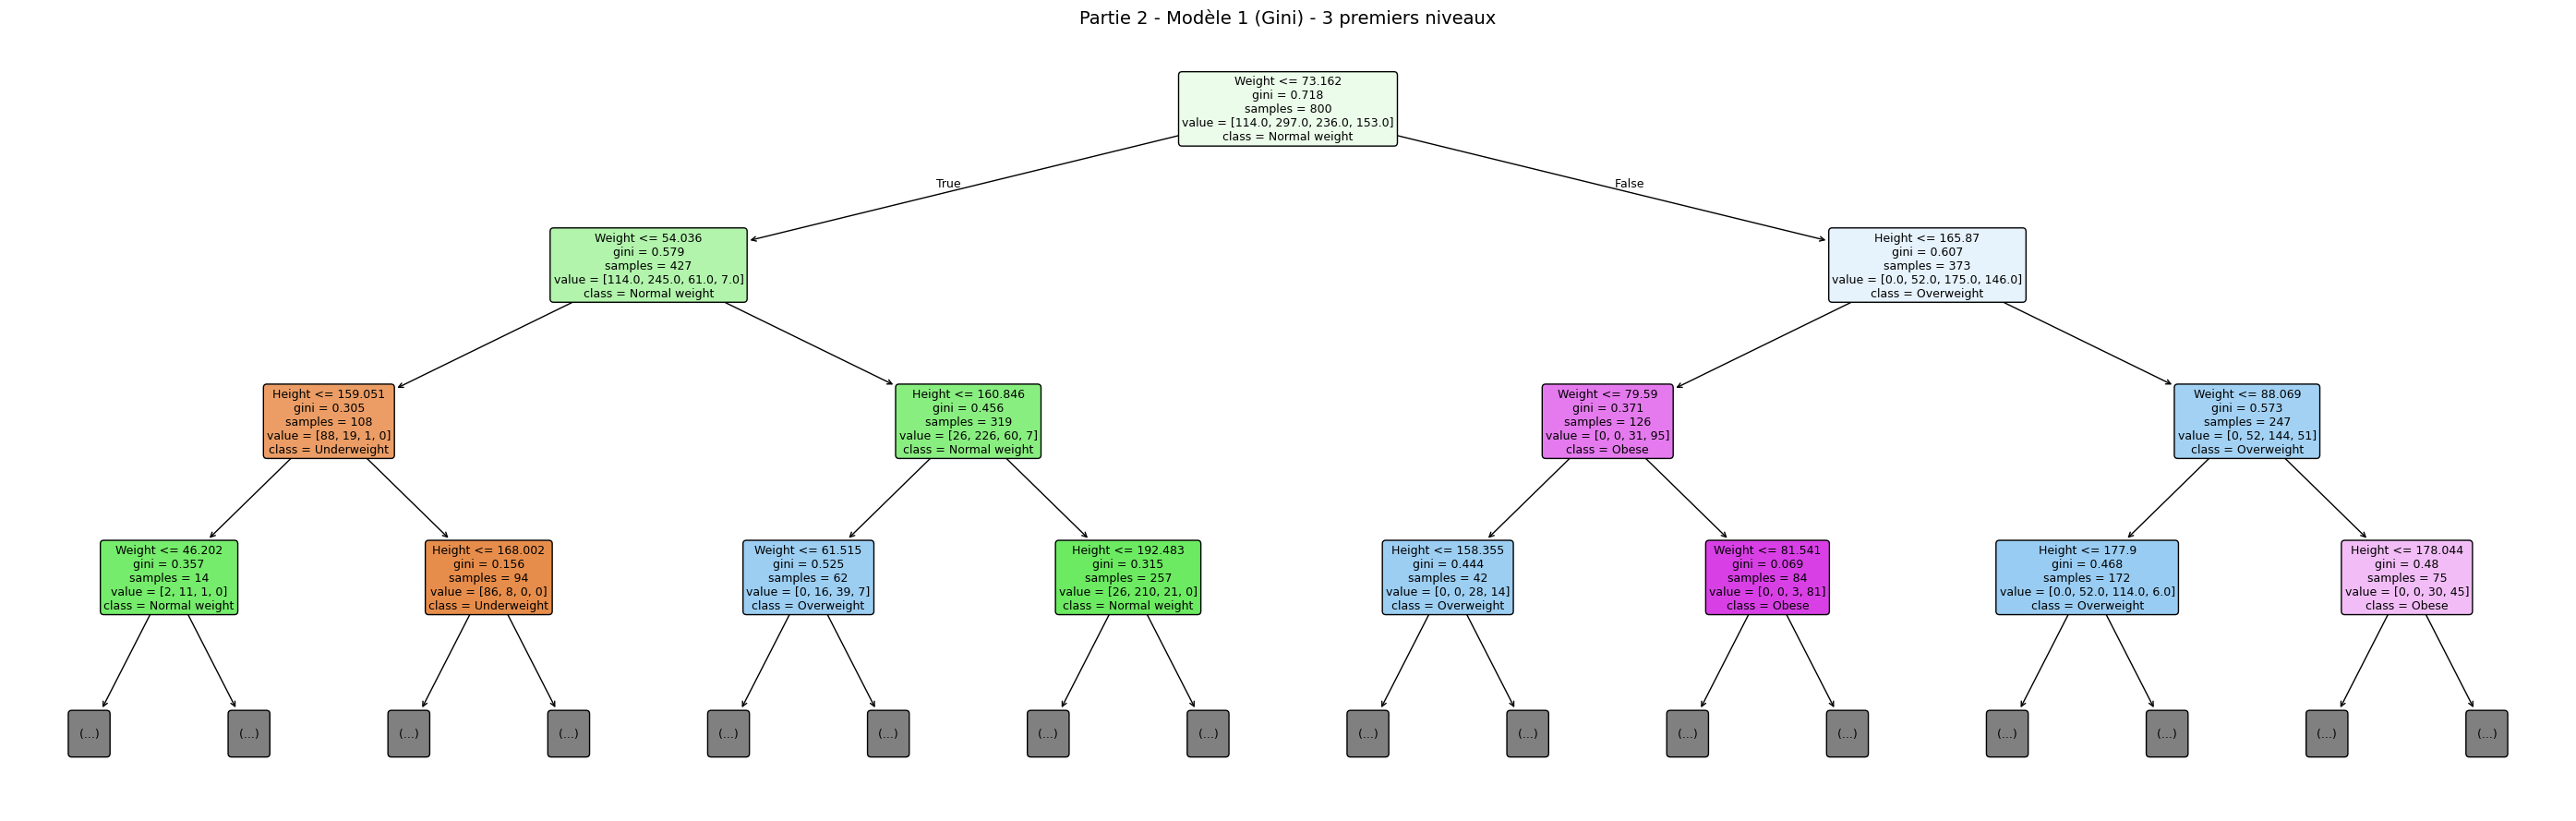

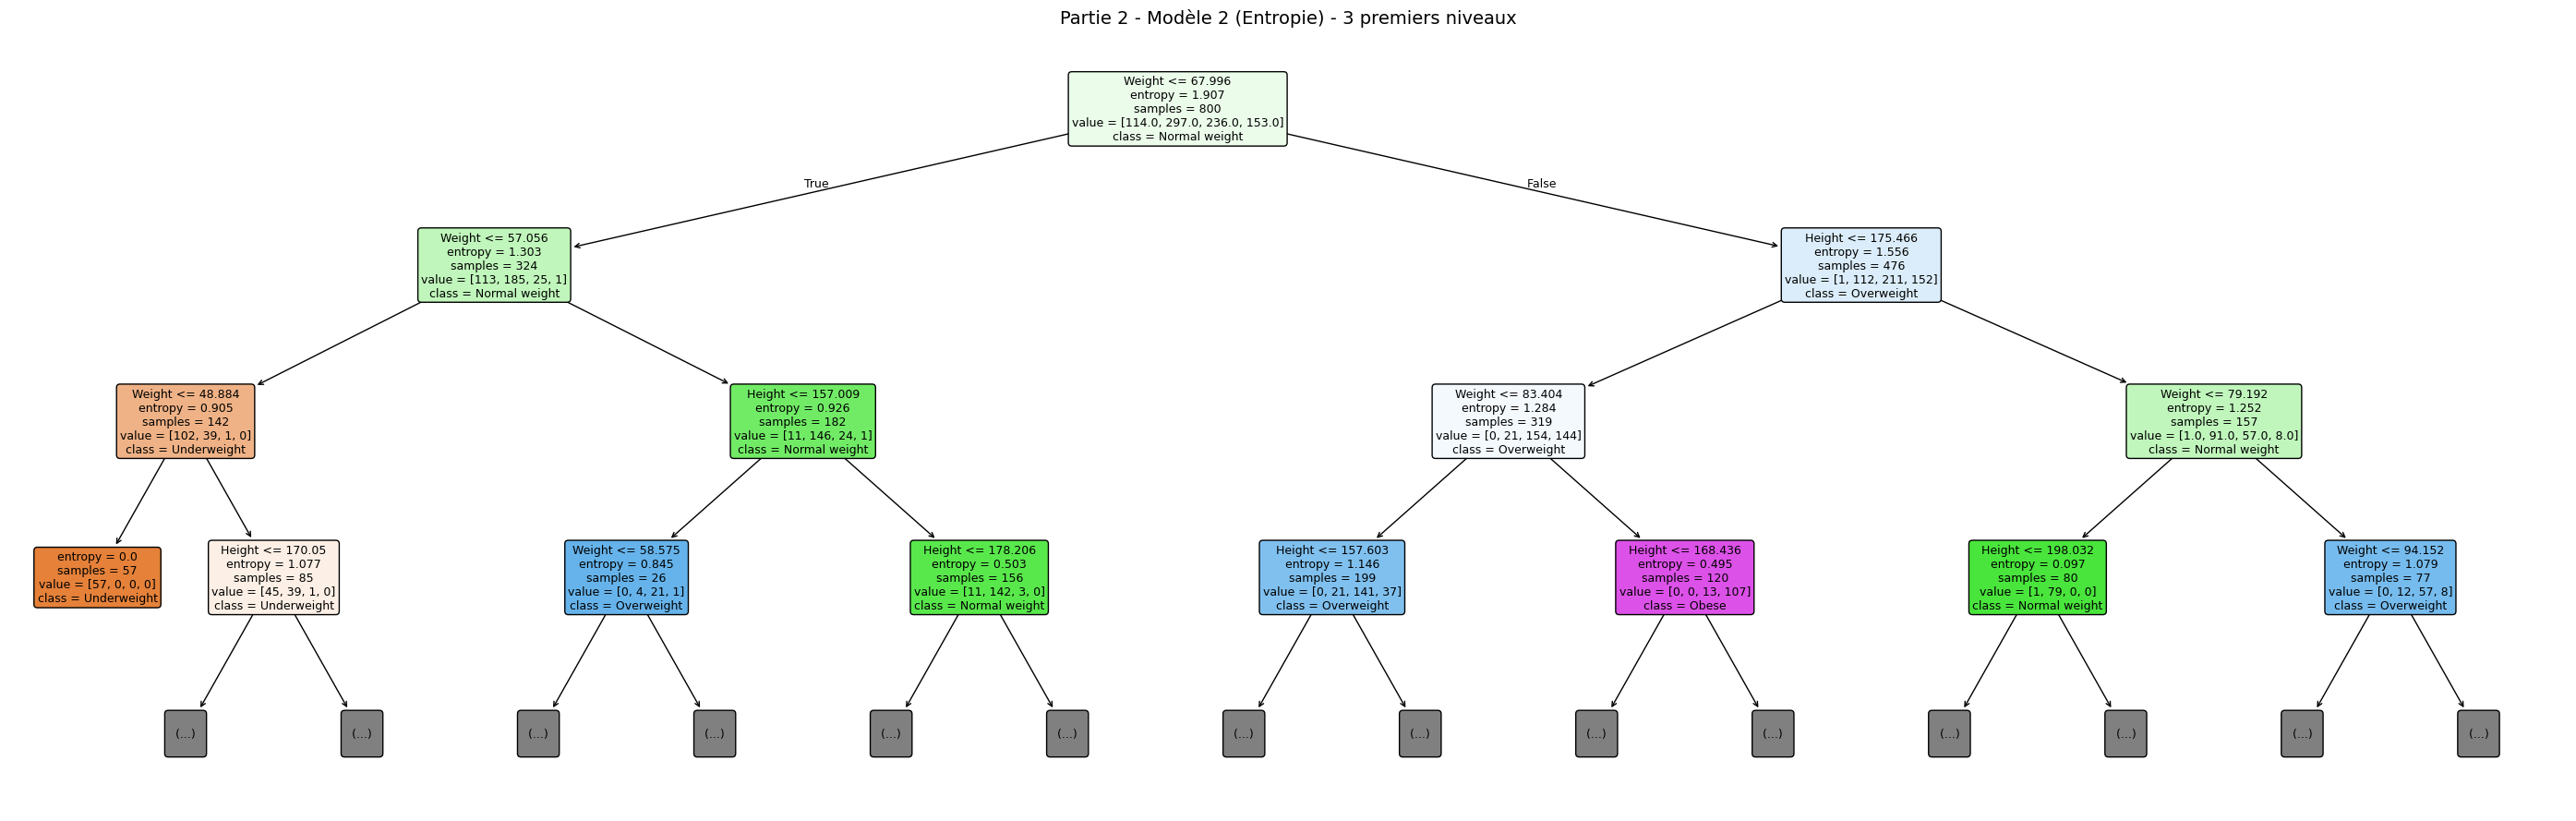

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

def afficher_seul(modele, feats, titre, max_depth=None, fichier=None):
    """Affiche UN arbre dans sa propre figure (et l'enregistre en PNG si 'fichier' est donné)."""
    largeur = 14 if modele.get_depth() <= 3 else 28
    fig, ax = plt.subplots(figsize=(largeur, 9))
    plot_tree(modele, feature_names=feats, class_names=ordre, filled=True,
              rounded=True, max_depth=max_depth, fontsize=9, ax=ax)
    ax.set_title(titre, fontsize=14)
    plt.tight_layout()
    if fichier:
        fig.savefig(fichier, dpi=200, bbox_inches="tight")
    plt.show()

F1, F2 = ["BMI"], ["Height", "Weight"]

# Partie 1 (avec BMI) : arbres complets
afficher_seul(modele1_p1, F1, "Partie 1 - Modèle 1 (Gini)",     fichier="arbre_P1_gini.png")
afficher_seul(modele2_p1, F1, "Partie 1 - Modèle 2 (Entropie)", fichier="arbre_P1_entropie.png")

# Partie 2 (sans BMI) : 3 premiers niveaux (changer max_depth pour voir plus profond)
afficher_seul(modele1_p2, F2, "Partie 2 - Modèle 1 (Gini) - 3 premiers niveaux",
              max_depth=3, fichier="arbre_P2_gini.png")
afficher_seul(modele2_p2, F2, "Partie 2 - Modèle 2 (Entropie) - 3 premiers niveaux",
              max_depth=3, fichier="arbre_P2_entropie.png")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Chemin du fichier :
/content/drive/MyDrive/Modélisation/obesity_binary.csv

Dossier de sortie :
/content/drive/MyDrive/Modélisation/resultats_ID3

Le fichier a été trouvé avec succès.

================ DONNÉES CHARGÉES ================
Dimensions du jeu de données :
(8, 7)

Contenu du jeu de données :


,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,0,0,1,0,0,1,0
1,1,1,0,1,1,0,1
2,0,1,1,1,1,0,1
3,1,0,1,1,1,0,1
4,1,1,0,0,0,1,0
5,0,0,0,1,1,1,1
6,0,1,1,0,0,1,0
7,1,0,0,1,1,0,1



Types des variables :
Age                      int64
Gender                   int64
Height                   int64
Weight                   int64
BMI                      int64
PhysicalActivityLevel    int64
ObesityCategory          int64
dtype: object

================ VARIABLES ================
Variable cible :
ObesityCategory

Attributs explicatifs :
['Age', 'Gender', 'Height', 'Weight', 'BMI', 'PhysicalActivityLevel']

Répartition de la cible :
ObesityCategory
1    5
0    3
Name: count, dtype: int64

================ ENTROPIE INITIALE ================
Entropie de la variable cible : 0.954434

================ GAINS D'INFORMATION ================


,Attribut,Information_Gain
0,Age,0.048795
1,Gender,0.048795
2,Height,0.048795
3,Weight,0.954434
4,BMI,0.954434
5,PhysicalActivityLevel,0.548795



Attributs ayant le gain maximal :
['Weight', 'BMI']

================ CHOIX DE LA RACINE ================
Attribut choisi comme racine :
BMI

Gain d'information de la racine :
0.954434

Remarque : BMI a été choisi en cas d'égalité avec Weight, car il est directement lié à la catégorie d'obésité.

================ ARBRE ID3 ================
Nœud : BMI | gain = 0.954434 | n = 8
  Si BMI == 0 :
    Feuille : classe = 0 (n = 3)
  Si BMI == 1 :
    Feuille : classe = 1 (n = 5)

================ STATISTIQUES DE L'ARBRE ================
Profondeur maximale de l'arbre ID3 : 1
Nombre de nœuds feuilles : 2


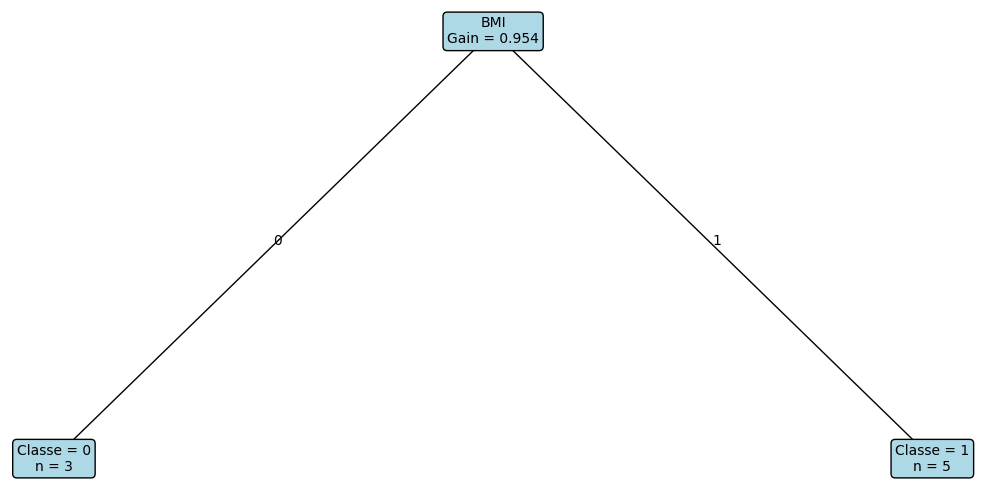


Image de l'arbre ID3 sauvegardée ici :
/content/drive/MyDrive/Modélisation/resultats_ID3/arbre_ID3_BMI.png

Tableau des gains sauvegardé ici :
/content/drive/MyDrive/Modélisation/resultats_ID3/gains_ID3.csv

Structure de l'arbre sauvegardée ici :
/content/drive/MyDrive/Modélisation/resultats_ID3/structure_arbre_ID3.txt

SECTION 2 — ID3 TERMINÉE
Variable cible : ObesityCategory
Attribut racine choisi : BMI
Profondeur maximale : 1
Nombre de feuilles : 2

Règle de l'arbre :
BMI = 0  --> classe 0
BMI = 1  --> classe 1

Tous les résultats sont enregistrés dans :
/content/drive/MyDrive/Modélisation/resultats_ID3


In [7]:
# ============================================================
# SECTION 2 — CONSTRUCTION D'UN ARBRE ID3
# Critère : Information Gain
# Variable cible : ObesityCategory
# Attribut racine choisi : BMI
# ============================================================


# ============================================================
# ÉTAPE 1 — IMPORTATION DES BIBLIOTHÈQUES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from math import log2
from pathlib import Path
from google.colab import drive


# ============================================================
# ÉTAPE 2 — CONNEXION À GOOGLE DRIVE
# ============================================================

drive.mount("/content/drive")


# ============================================================
# ÉTAPE 3 — DÉFINITION DES CHEMINS
# ============================================================

# Chemin du fichier binaire
chemin_fichier = (
    "/content/drive/MyDrive/"
    "Modélisation/obesity_binary.csv"
)

# Dossier où les résultats seront sauvegardés
dossier_sortie = Path(
    "/content/drive/MyDrive/"
    "Modélisation/resultats_ID3"
)

dossier_sortie.mkdir(
    parents=True,
    exist_ok=True
)

print("Chemin du fichier :")
print(chemin_fichier)

print("\nDossier de sortie :")
print(dossier_sortie)


# ============================================================
# ÉTAPE 4 — VÉRIFICATION DE L'EXISTENCE DU FICHIER
# ============================================================

if not Path(chemin_fichier).exists():

    raise FileNotFoundError(
        "\nLe fichier obesity_binary.csv est introuvable.\n"
        "Vérifiez que le fichier se trouve dans :\n"
        "/content/drive/MyDrive/Modélisation/"
    )

print("\nLe fichier a été trouvé avec succès.")


# ============================================================
# ÉTAPE 5 — CHARGEMENT DES DONNÉES
# ============================================================

data = pd.read_csv(chemin_fichier)

# Conversion de toutes les colonnes en valeurs entières
data = data.astype(int)

print("\n================ DONNÉES CHARGÉES ================")

print("Dimensions du jeu de données :")
print(data.shape)

print("\nContenu du jeu de données :")
display(data)

print("\nTypes des variables :")
print(data.dtypes)


# ============================================================
# ÉTAPE 6 — DÉFINITION DE LA CIBLE ET DES ATTRIBUTS
# ============================================================

# Variable cible
target = "ObesityCategory"

# Attributs explicatifs
features = [
    colonne
    for colonne in data.columns
    if colonne != target
]

print("\n================ VARIABLES ================")

print("Variable cible :")
print(target)

print("\nAttributs explicatifs :")
print(features)

print("\nRépartition de la cible :")
print(data[target].value_counts())


# ============================================================
# ÉTAPE 7 — CALCUL DE L'ENTROPIE
# ============================================================

def entropy(values):
    """
    Calcule l'entropie de Shannon.

    Une entropie élevée signifie que les classes
    sont fortement mélangées.

    Une entropie égale à zéro signifie que toutes
    les observations appartiennent à la même classe.
    """

    # Effectif de chaque classe
    effectifs = pd.Series(values).value_counts()

    # Nombre total d'observations
    total = len(values)

    # Initialisation de l'entropie
    entropie = 0

    # Calcul de l'entropie
    for effectif in effectifs:

        probabilite = effectif / total

        entropie -= (
            probabilite
            * log2(probabilite)
        )

    return entropie


# Calcul de l'entropie initiale
entropie_initiale = entropy(
    data[target]
)

print("\n================ ENTROPIE INITIALE ================")

print(
    "Entropie de la variable cible :",
    round(entropie_initiale, 6)
)


# ============================================================
# ÉTAPE 8 — CALCUL DU GAIN D'INFORMATION
# ============================================================

def information_gain(
    dataframe,
    feature,
    target
):
    """
    Calcule le gain d'information d'un attribut.

    Gain(S,A) =
    Entropie(S) - Entropie(S après séparation selon A)
    """

    # Entropie avant la séparation
    entropie_parent = entropy(
        dataframe[target]
    )

    # Nombre total d'observations
    total = len(dataframe)

    # Entropie pondérée après séparation
    entropie_apres_separation = 0

    # Séparation selon chaque valeur de l'attribut
    for valeur, groupe in dataframe.groupby(
        feature,
        sort=False
    ):

        # Poids du groupe
        poids = len(groupe) / total

        # Entropie du groupe
        entropie_groupe = entropy(
            groupe[target]
        )

        # Contribution du groupe
        entropie_apres_separation += (
            poids
            * entropie_groupe
        )

    # Gain d'information
    gain = (
        entropie_parent
        - entropie_apres_separation
    )

    return gain


# ============================================================
# ÉTAPE 9 — CALCUL DU GAIN DE CHAQUE ATTRIBUT
# ============================================================

resultats_gain = []

for feature in features:

    gain = information_gain(
        data,
        feature,
        target
    )

    resultats_gain.append({
        "Attribut": feature,
        "Information_Gain": gain
    })

tableau_gain = pd.DataFrame(
    resultats_gain
)

print("\n================ GAINS D'INFORMATION ================")

display(
    tableau_gain.round(6)
)


# ============================================================
# ÉTAPE 10 — SÉLECTION DE LA RACINE
# ============================================================

# Gain maximal
gain_maximal = tableau_gain[
    "Information_Gain"
].max()

# Attributs ayant le gain maximal
attributs_meilleurs = tableau_gain[
    np.isclose(
        tableau_gain["Information_Gain"],
        gain_maximal
    )
]["Attribut"].tolist()

print("\nAttributs ayant le gain maximal :")
print(attributs_meilleurs)

# Règle de départage :
# BMI est prioritaire en cas d'égalité avec Weight
if "BMI" in attributs_meilleurs:

    attribut_racine = "BMI"

else:

    attribut_racine = attributs_meilleurs[0]

print("\n================ CHOIX DE LA RACINE ================")

print("Attribut choisi comme racine :")
print(attribut_racine)

print("\nGain d'information de la racine :")
print(round(gain_maximal, 6))

print(
    "\nRemarque : BMI a été choisi en cas d'égalité "
    "avec Weight, car il est directement lié à la "
    "catégorie d'obésité."
)


# ============================================================
# ÉTAPE 11 — CONSTRUCTION RÉCURSIVE DE L'ARBRE ID3
# ============================================================

def build_id3_tree(
    dataframe,
    available_features,
    target
):
    """
    Construit récursivement un arbre ID3.

    Le choix de chaque nœud est effectué
    selon le gain d'information.

    En cas d'égalité, BMI est prioritaire.
    """

    # --------------------------------------------------------
    # Cas d'arrêt 1 :
    # toutes les observations appartiennent
    # à la même classe
    # --------------------------------------------------------

    if dataframe[target].nunique() == 1:

        classe = int(
            dataframe[target].iloc[0]
        )

        return {
            "type": "leaf",
            "class": classe,
            "n": len(dataframe)
        }

    # --------------------------------------------------------
    # Cas d'arrêt 2 :
    # aucun attribut ne reste disponible
    # --------------------------------------------------------

    if len(available_features) == 0:

        classe_majoritaire = int(
            dataframe[target].mode().iloc[0]
        )

        return {
            "type": "leaf",
            "class": classe_majoritaire,
            "n": len(dataframe)
        }

    # --------------------------------------------------------
    # Calcul des gains des attributs disponibles
    # --------------------------------------------------------

    gains = {}

    for feature in available_features:

        gains[feature] = information_gain(
            dataframe,
            feature,
            target
        )

    # --------------------------------------------------------
    # Identification du gain maximal
    # --------------------------------------------------------

    gain_maximal = max(
        gains.values()
    )

    # Attributs ayant le gain maximal
    attributs_meilleurs = [
        attribut
        for attribut, gain in gains.items()
        if np.isclose(
            gain,
            gain_maximal
        )
    ]

    # --------------------------------------------------------
    # Règle de départage
    # BMI est choisi en priorité
    # --------------------------------------------------------

    if "BMI" in attributs_meilleurs:

        meilleur_attribut = "BMI"

    else:

        meilleur_attribut = attributs_meilleurs[0]

    # --------------------------------------------------------
    # Création du nœud
    # --------------------------------------------------------

    node = {
        "type": "node",
        "attribute": meilleur_attribut,
        "gain": gains[meilleur_attribut],
        "n": len(dataframe),
        "children": {}
    }

    # Retirer l'attribut déjà utilisé
    attributs_restants = [
        feature
        for feature in available_features
        if feature != meilleur_attribut
    ]

    # --------------------------------------------------------
    # Création des branches
    # --------------------------------------------------------

    for valeur, sous_ensemble in dataframe.groupby(
        meilleur_attribut,
        sort=True
    ):

        sous_arbre = build_id3_tree(
            sous_ensemble,
            attributs_restants,
            target
        )

        node["children"][int(valeur)] = sous_arbre

    return node


# Construction de l'arbre ID3
arbre_id3 = build_id3_tree(
    data,
    features,
    target
)


# ============================================================
# ÉTAPE 12 — AFFICHAGE TEXTUEL DE L'ARBRE
# ============================================================

def print_id3_tree(
    tree,
    indentation=""
):
    """
    Affiche l'arbre ID3 sous forme textuelle.
    """

    # Si le nœud est une feuille
    if tree["type"] == "leaf":

        print(
            f"{indentation}Feuille : "
            f"classe = {tree['class']} "
            f"(n = {tree['n']})"
        )

        return

    # Affichage du nœud
    print(
        f"{indentation}Nœud : "
        f"{tree['attribute']} "
        f"| gain = {tree['gain']:.6f} "
        f"| n = {tree['n']}"
    )

    # Affichage des branches
    for valeur, enfant in tree["children"].items():

        print(
            f"{indentation}  Si "
            f"{tree['attribute']} == {valeur} :"
        )

        print_id3_tree(
            enfant,
            indentation + "    "
        )


print("\n================ ARBRE ID3 ================")

print_id3_tree(
    arbre_id3
)


# ============================================================
# ÉTAPE 13 — PROFONDEUR ET NOMBRE DE FEUILLES
# ============================================================

def tree_statistics(tree):
    """
    Retourne :

    - la profondeur maximale de l'arbre ;
    - le nombre total de feuilles.
    """

    # Une feuille possède une profondeur zéro
    if tree["type"] == "leaf":

        return 0, 1

    profondeurs = []
    nombre_feuilles = 0

    # Analyse récursive des enfants
    for enfant in tree["children"].values():

        profondeur, feuilles = tree_statistics(
            enfant
        )

        profondeurs.append(profondeur)
        nombre_feuilles += feuilles

    profondeur_maximale = (
        1
        + max(profondeurs)
    )

    return profondeur_maximale, nombre_feuilles


profondeur_id3, feuilles_id3 = (
    tree_statistics(arbre_id3)
)

print("\n================ STATISTIQUES DE L'ARBRE ================")

print(
    "Profondeur maximale de l'arbre ID3 :",
    profondeur_id3
)

print(
    "Nombre de nœuds feuilles :",
    feuilles_id3
)


# ============================================================
# ÉTAPE 14 — VISUALISATION DE L'ARBRE
# ============================================================

def draw_tree(
    tree,
    output_path
):
    """
    Dessine et sauvegarde l'arbre ID3.
    """

    positions = {}
    labels = {}
    edges = []

    compteur = [0]

    def visit(
        node,
        profondeur=0,
        parent=None,
        label_branche=""
    ):
        """
        Positionne récursivement les nœuds.
        """

        node_id = compteur[0]
        compteur[0] += 1

        # Texte d'une feuille
        if node["type"] == "leaf":

            labels[node_id] = (
                f"Classe = {node['class']}\n"
                f"n = {node['n']}"
            )

        # Texte d'un nœud interne
        else:

            labels[node_id] = (
                f"{node['attribute']}\n"
                f"Gain = {node['gain']:.3f}"
            )

        # Récupération des enfants
        enfants = list(
            node.get("children", {}).items()
        )

        if enfants:

            positions_enfants = []

            for valeur, enfant in enfants:

                position_x = visit(
                    enfant,
                    profondeur + 1,
                    node_id,
                    str(valeur)
                )

                positions_enfants.append(
                    position_x
                )

            position_x = np.mean(
                positions_enfants
            )

            positions[node_id] = (
                position_x,
                -profondeur
            )

        else:

            positions[node_id] = (
                node_id,
                -profondeur
            )

        # Ajouter une arête vers le parent
        if parent is not None:

            edges.append(
                (
                    parent,
                    node_id,
                    label_branche
                )
            )

        return positions[node_id][0]

    # Lancer le positionnement
    visit(tree)

    figure, axis = plt.subplots(
        figsize=(10, 5)
    )

    # Dessiner les branches
    for parent, child, label in edges:

        x1, y1 = positions[parent]
        x2, y2 = positions[child]

        axis.plot(
            [x1, x2],
            [y1, y2],
            color="black",
            linewidth=1
        )

        axis.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            label,
            fontsize=10
        )

    # Dessiner les nœuds
    for node_id, text in labels.items():

        x, y = positions[node_id]

        axis.text(
            x,
            y,
            text,
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round",
                facecolor="lightblue",
                edgecolor="black"
            )
        )

    axis.axis("off")

    figure.tight_layout()

    figure.savefig(
        output_path,
        dpi=150
    )

    plt.show()
    plt.close()


# Chemin de sauvegarde de l'image
chemin_image = (
    dossier_sortie / "arbre_ID3_BMI.png"
)

# Création de la visualisation
draw_tree(
    arbre_id3,
    chemin_image
)

print("\nImage de l'arbre ID3 sauvegardée ici :")
print(chemin_image)


# ============================================================
# ÉTAPE 15 — EXPORT DES RÉSULTATS
# ============================================================

# Export du tableau des gains
tableau_gain.round(6).to_csv(
    dossier_sortie / "gains_ID3.csv",
    index=False
)

# Export de la structure de l'arbre
with open(
    dossier_sortie / "structure_arbre_ID3.txt",
    "w",
    encoding="utf-8"
) as fichier_sortie:

    # Rediriger temporairement l'affichage vers une chaîne
    import io
    from contextlib import redirect_stdout

    contenu = io.StringIO()

    with redirect_stdout(contenu):
        print_id3_tree(arbre_id3)

    fichier_sortie.write(
        contenu.getvalue()
    )

print("\nTableau des gains sauvegardé ici :")
print(dossier_sortie / "gains_ID3.csv")

print("\nStructure de l'arbre sauvegardée ici :")
print(dossier_sortie / "structure_arbre_ID3.txt")


# ============================================================
# ÉTAPE 16 — RÉSUMÉ FINAL
# ============================================================

print("\n============================================================")
print("SECTION 2 — ID3 TERMINÉE")
print("============================================================")

print("Variable cible :", target)
print("Attribut racine choisi :", arbre_id3["attribute"])
print("Profondeur maximale :", profondeur_id3)
print("Nombre de feuilles :", feuilles_id3)

print("\nRègle de l'arbre :")
print("BMI = 0  --> classe 0")
print("BMI = 1  --> classe 1")

print("\nTous les résultats sont enregistrés dans :")
print(dossier_sortie)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Chemin du fichier :
/content/drive/MyDrive/Modélisation/obesity_binary.csv

Dossier de sortie :
/content/drive/MyDrive/Modélisation/resultats_C45

Le fichier a été trouvé avec succès.

================ DONNÉES CHARGÉES ================
Dimensions du jeu de données :
(8, 7)

Contenu du jeu de données :


,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,0,0,1,0,0,1,0
1,1,1,0,1,1,0,1
2,0,1,1,1,1,0,1
3,1,0,1,1,1,0,1
4,1,1,0,0,0,1,0
5,0,0,0,1,1,1,1
6,0,1,1,0,0,1,0
7,1,0,0,1,1,0,1



Types des variables :
Age                      int64
Gender                   int64
Height                   int64
Weight                   int64
BMI                      int64
PhysicalActivityLevel    int64
ObesityCategory          int64
dtype: object

================ VARIABLES ================
Variable cible :
ObesityCategory

Attributs explicatifs :
['Age', 'Gender', 'Height', 'Weight', 'BMI', 'PhysicalActivityLevel']

Répartition de la cible :
ObesityCategory
1    5
0    3
Name: count, dtype: int64

================ ENTROPIE INITIALE ================
Entropie de la variable cible : 0.954434

================ SCORES C4.5 ================


,Attribut,Information_Gain,Split_Information,Gain_Ratio
0,Age,0.048795,1.000000,0.048795
1,Gender,0.048795,1.000000,0.048795
2,Height,0.048795,1.000000,0.048795
3,Weight,0.954434,0.954434,1.000000
4,BMI,0.954434,0.954434,1.000000
5,PhysicalActivityLevel,0.548795,1.000000,0.548795



Attributs ayant le Gain Ratio maximal :
['Weight', 'BMI']

================ CHOIX DE LA RACINE ================
Attribut choisi comme racine C4.5 :
BMI

Gain Ratio de la racine :
1.0

Remarque : BMI a été choisi en cas d'égalité avec Weight, car il est directement lié à la catégorie d'obésité.

================ ARBRE C4.5 ================
Nœud : BMI | Gain Ratio = 1.000000 | n = 8
  Si BMI == 0 :
    Feuille : classe = 0 (n = 3)
  Si BMI == 1 :
    Feuille : classe = 1 (n = 5)

================ STATISTIQUES DE L'ARBRE ================
Profondeur maximale de l'arbre C4.5 : 1
Nombre de nœuds feuilles : 2


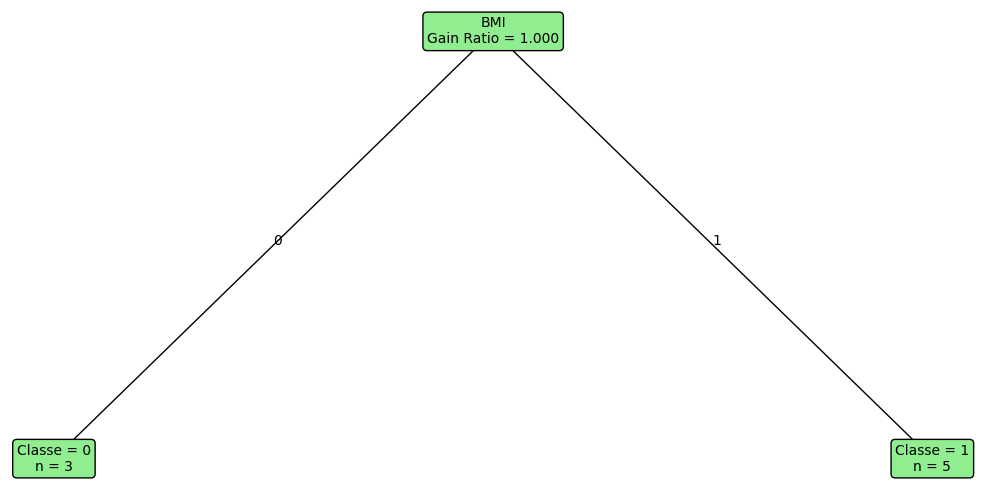


Image de l'arbre C4.5 sauvegardée ici :
/content/drive/MyDrive/Modélisation/resultats_C45/arbre_C45_BMI.png

SECTION 3 — C4.5 TERMINÉE
Variable cible : ObesityCategory
Attribut racine choisi : BMI
Profondeur maximale : 1
Nombre de feuilles : 2

Structure de l'arbre :
BMI = 0  --> classe 0
BMI = 1  --> classe 1

Fichiers enregistrés dans :
/content/drive/MyDrive/Modélisation/resultats_C45

Fichiers produits :
- scores_C45.csv
- structure_arbre_C45.txt
- arbre_C45_BMI.png


In [8]:
# ============================================================
# SECTION 3 — CONSTRUCTION D'UN ARBRE C4.5
# Critère : Gain Ratio
# Variable cible : ObesityCategory
# Attribut racine choisi : BMI
# ============================================================


# ============================================================
# ÉTAPE 1 — IMPORTATION DES BIBLIOTHÈQUES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from math import log2
from pathlib import Path
from google.colab import drive


# ============================================================
# ÉTAPE 2 — CONNEXION À GOOGLE DRIVE
# ============================================================

drive.mount("/content/drive")


# ============================================================
# ÉTAPE 3 — DÉFINITION DES CHEMINS
# ============================================================

# Chemin du fichier binaire
chemin_fichier = (
    "/content/drive/MyDrive/"
    "Modélisation/obesity_binary.csv"
)

# Dossier de sortie pour les résultats C4.5
dossier_sortie = Path(
    "/content/drive/MyDrive/"
    "Modélisation/resultats_C45"
)

dossier_sortie.mkdir(
    parents=True,
    exist_ok=True
)

print("Chemin du fichier :")
print(chemin_fichier)

print("\nDossier de sortie :")
print(dossier_sortie)


# ============================================================
# ÉTAPE 4 — VÉRIFICATION DU FICHIER
# ============================================================

if not Path(chemin_fichier).exists():

    raise FileNotFoundError(
        "\nLe fichier obesity_binary.csv est introuvable.\n"
        "Vérifiez qu'il se trouve dans :\n"
        "/content/drive/MyDrive/Modélisation/"
    )

print("\nLe fichier a été trouvé avec succès.")


# ============================================================
# ÉTAPE 5 — CHARGEMENT DES DONNÉES
# ============================================================

data = pd.read_csv(chemin_fichier)

# Conversion des colonnes en entiers
data = data.astype(int)

print("\n================ DONNÉES CHARGÉES ================")

print("Dimensions du jeu de données :")
print(data.shape)

print("\nContenu du jeu de données :")
display(data)

print("\nTypes des variables :")
print(data.dtypes)


# ============================================================
# ÉTAPE 6 — DÉFINITION DE LA CIBLE ET DES ATTRIBUTS
# ============================================================

# Variable cible
target = "ObesityCategory"

# Variables explicatives
features = [
    colonne
    for colonne in data.columns
    if colonne != target
]

print("\n================ VARIABLES ================")

print("Variable cible :")
print(target)

print("\nAttributs explicatifs :")
print(features)

print("\nRépartition de la cible :")
print(data[target].value_counts())


# ============================================================
# ÉTAPE 7 — CALCUL DE L'ENTROPIE
# ============================================================

def entropy(values):
    """
    Calcule l'entropie de Shannon.

    Une entropie élevée signifie que les classes
    sont mélangées.

    Une entropie égale à zéro signifie que toutes
    les observations appartiennent à une seule classe.
    """

    # Nombre d'observations dans chaque classe
    effectifs = pd.Series(values).value_counts()

    # Nombre total d'observations
    total = len(values)

    entropie = 0

    for effectif in effectifs:

        # Probabilité de la classe
        probabilite = effectif / total

        # Formule de Shannon
        entropie -= (
            probabilite
            * log2(probabilite)
        )

    return entropie


# Entropie initiale de la cible
entropie_initiale = entropy(
    data[target]
)

print("\n================ ENTROPIE INITIALE ================")

print(
    "Entropie de la variable cible :",
    round(entropie_initiale, 6)
)


# ============================================================
# ÉTAPE 8 — CALCUL DU GAIN D'INFORMATION
# ============================================================

def information_gain(
    dataframe,
    feature,
    target
):
    """
    Calcule le gain d'information d'un attribut.

    Gain(S,A) =
    Entropie avant séparation
    - Entropie après séparation
    """

    # Entropie du nœud parent
    entropie_parent = entropy(
        dataframe[target]
    )

    # Nombre total d'observations
    total = len(dataframe)

    # Entropie pondérée des sous-groupes
    entropie_apres_separation = 0

    # Séparation du jeu selon les valeurs de l'attribut
    for valeur, groupe in dataframe.groupby(
        feature,
        sort=False
    ):

        # Poids du groupe
        poids = len(groupe) / total

        # Entropie du groupe
        entropie_groupe = entropy(
            groupe[target]
        )

        # Contribution du groupe
        entropie_apres_separation += (
            poids
            * entropie_groupe
        )

    # Calcul du gain d'information
    gain = (
        entropie_parent
        - entropie_apres_separation
    )

    return gain


# ============================================================
# ÉTAPE 9 — CALCUL DU SPLIT INFORMATION
# ============================================================

def split_information(values):
    """
    Calcule le Split Information.

    Le Split Information mesure la dispersion
    des observations entre les différentes branches.
    """

    # Effectif de chaque valeur de l'attribut
    effectifs = pd.Series(values).value_counts()

    # Nombre total d'observations
    total = len(values)

    split_info = 0

    for effectif in effectifs:

        # Probabilité de la branche
        probabilite = effectif / total

        # Formule du Split Information
        split_info -= (
            probabilite
            * log2(probabilite)
        )

    return split_info


# ============================================================
# ÉTAPE 10 — CALCUL DU GAIN RATIO
# ============================================================

def gain_ratio(
    dataframe,
    feature,
    target
):
    """
    Calcule le Gain Ratio utilisé par C4.5.

    Gain Ratio =
    Information Gain / Split Information
    """

    # Calcul du gain d'information
    gain = information_gain(
        dataframe,
        feature,
        target
    )

    # Calcul du Split Information
    split_info = split_information(
        dataframe[feature]
    )

    # Éviter la division par zéro
    if split_info == 0:

        return 0

    return gain / split_info


# ============================================================
# ÉTAPE 11 — CALCUL DES SCORES POUR TOUS LES ATTRIBUTS
# ============================================================

resultats_c45 = []

for feature in features:

    gain = information_gain(
        data,
        feature,
        target
    )

    split_info = split_information(
        data[feature]
    )

    ratio = gain_ratio(
        data,
        feature,
        target
    )

    resultats_c45.append({
        "Attribut": feature,
        "Information_Gain": gain,
        "Split_Information": split_info,
        "Gain_Ratio": ratio
    })


tableau_c45 = pd.DataFrame(
    resultats_c45
)

print("\n================ SCORES C4.5 ================")

display(
    tableau_c45.round(6)
)


# ============================================================
# ÉTAPE 12 — CHOIX DE LA RACINE
# ============================================================

# Gain Ratio maximal
gain_ratio_maximal = tableau_c45[
    "Gain_Ratio"
].max()

# Attributs ayant le Gain Ratio maximal
attributs_meilleurs = tableau_c45[
    np.isclose(
        tableau_c45["Gain_Ratio"],
        gain_ratio_maximal
    )
]["Attribut"].tolist()

print("\nAttributs ayant le Gain Ratio maximal :")
print(attributs_meilleurs)

# Règle de départage :
# priorité donnée à BMI en cas d'égalité
if "BMI" in attributs_meilleurs:

    attribut_racine = "BMI"

else:

    attribut_racine = attributs_meilleurs[0]

print("\n================ CHOIX DE LA RACINE ================")

print("Attribut choisi comme racine C4.5 :")
print(attribut_racine)

print("\nGain Ratio de la racine :")
print(round(gain_ratio_maximal, 6))

print(
    "\nRemarque : BMI a été choisi en cas d'égalité "
    "avec Weight, car il est directement lié à la "
    "catégorie d'obésité."
)


# ============================================================
# ÉTAPE 13 — CONSTRUCTION RÉCURSIVE DE L'ARBRE C4.5
# ============================================================

def build_c45_tree(
    dataframe,
    available_features,
    target
):
    """
    Construit récursivement un arbre C4.5.

    Le critère de sélection est le Gain Ratio.

    En cas d'égalité entre BMI et Weight,
    BMI est choisi en priorité.
    """

    # --------------------------------------------------------
    # Cas d'arrêt 1 :
    # toutes les observations ont la même classe
    # --------------------------------------------------------

    if dataframe[target].nunique() == 1:

        classe = int(
            dataframe[target].iloc[0]
        )

        return {
            "type": "leaf",
            "class": classe,
            "n": len(dataframe)
        }

    # --------------------------------------------------------
    # Cas d'arrêt 2 :
    # aucun attribut restant
    # --------------------------------------------------------

    if len(available_features) == 0:

        classe_majoritaire = int(
            dataframe[target].mode().iloc[0]
        )

        return {
            "type": "leaf",
            "class": classe_majoritaire,
            "n": len(dataframe)
        }

    # --------------------------------------------------------
    # Calcul du Gain Ratio de chaque attribut
    # --------------------------------------------------------

    ratios = {}

    for feature in available_features:

        ratios[feature] = gain_ratio(
            dataframe,
            feature,
            target
        )

    # --------------------------------------------------------
    # Identification du Gain Ratio maximal
    # --------------------------------------------------------

    gain_ratio_maximal = max(
        ratios.values()
    )

    # Attributs ayant le meilleur score
    attributs_meilleurs = [
        attribut
        for attribut, ratio in ratios.items()
        if np.isclose(
            ratio,
            gain_ratio_maximal
        )
    ]

    # --------------------------------------------------------
    # Règle de départage :
    # BMI est prioritaire
    # --------------------------------------------------------

    if "BMI" in attributs_meilleurs:

        meilleur_attribut = "BMI"

    else:

        meilleur_attribut = attributs_meilleurs[0]

    # --------------------------------------------------------
    # Création du nœud
    # --------------------------------------------------------

    node = {
        "type": "node",
        "attribute": meilleur_attribut,
        "gain_ratio": ratios[meilleur_attribut],
        "n": len(dataframe),
        "children": {}
    }

    # Retirer l'attribut déjà utilisé
    attributs_restants = [
        feature
        for feature in available_features
        if feature != meilleur_attribut
    ]

    # --------------------------------------------------------
    # Création des branches
    # --------------------------------------------------------

    for valeur, sous_ensemble in dataframe.groupby(
        meilleur_attribut,
        sort=True
    ):

        sous_arbre = build_c45_tree(
            sous_ensemble,
            attributs_restants,
            target
        )

        node["children"][int(valeur)] = sous_arbre

    return node


# Construction de l'arbre C4.5
arbre_c45 = build_c45_tree(
    data,
    features,
    target
)


# ============================================================
# ÉTAPE 14 — AFFICHAGE TEXTUEL DE L'ARBRE
# ============================================================

def print_c45_tree(
    tree,
    indentation=""
):
    """
    Affiche l'arbre C4.5 sous forme textuelle.
    """

    # Si le nœud est une feuille
    if tree["type"] == "leaf":

        print(
            f"{indentation}Feuille : "
            f"classe = {tree['class']} "
            f"(n = {tree['n']})"
        )

        return

    # Affichage du nœud interne
    print(
        f"{indentation}Nœud : "
        f"{tree['attribute']} "
        f"| Gain Ratio = "
        f"{tree['gain_ratio']:.6f} "
        f"| n = {tree['n']}"
    )

    # Affichage des branches
    for valeur, enfant in tree["children"].items():

        print(
            f"{indentation}  Si "
            f"{tree['attribute']} == {valeur} :"
        )

        print_c45_tree(
            enfant,
            indentation + "    "
        )


print("\n================ ARBRE C4.5 ================")

print_c45_tree(
    arbre_c45
)


# ============================================================
# ÉTAPE 15 — CALCUL DE LA PROFONDEUR ET DES FEUILLES
# ============================================================

def tree_statistics(tree):
    """
    Retourne :

    - la profondeur maximale ;
    - le nombre de feuilles.
    """

    # Une feuille possède une profondeur zéro
    if tree["type"] == "leaf":

        return 0, 1

    profondeurs = []
    nombre_feuilles = 0

    # Analyse récursive des enfants
    for enfant in tree["children"].values():

        profondeur, feuilles = tree_statistics(
            enfant
        )

        profondeurs.append(profondeur)
        nombre_feuilles += feuilles

    profondeur_maximale = (
        1
        + max(profondeurs)
    )

    return profondeur_maximale, nombre_feuilles


profondeur_c45, feuilles_c45 = (
    tree_statistics(arbre_c45)
)

print("\n================ STATISTIQUES DE L'ARBRE ================")

print(
    "Profondeur maximale de l'arbre C4.5 :",
    profondeur_c45
)

print(
    "Nombre de nœuds feuilles :",
    feuilles_c45
)


# ============================================================
# ÉTAPE 16 — VISUALISATION GRAPHIQUE DE L'ARBRE
# ============================================================

def draw_tree(
    tree,
    output_path
):
    """
    Dessine et sauvegarde l'arbre C4.5.
    """

    positions = {}
    labels = {}
    edges = []

    compteur = [0]

    def visit(
        node,
        profondeur=0,
        parent=None,
        label_branche=""
    ):
        """
        Positionne récursivement les nœuds.
        """

        node_id = compteur[0]
        compteur[0] += 1

        # Étiquette d'une feuille
        if node["type"] == "leaf":

            labels[node_id] = (
                f"Classe = {node['class']}\n"
                f"n = {node['n']}"
            )

        # Étiquette d'un nœud interne
        else:

            labels[node_id] = (
                f"{node['attribute']}\n"
                f"Gain Ratio = "
                f"{node['gain_ratio']:.3f}"
            )

        # Récupérer les enfants
        enfants = list(
            node.get("children", {}).items()
        )

        if enfants:

            positions_enfants = []

            for valeur, enfant in enfants:

                position_x = visit(
                    enfant,
                    profondeur + 1,
                    node_id,
                    str(valeur)
                )

                positions_enfants.append(
                    position_x
                )

            position_x = np.mean(
                positions_enfants
            )

            positions[node_id] = (
                position_x,
                -profondeur
            )

        else:

            positions[node_id] = (
                node_id,
                -profondeur
            )

        # Ajouter l'arête vers le parent
        if parent is not None:

            edges.append(
                (
                    parent,
                    node_id,
                    label_branche
                )
            )

        return positions[node_id][0]

    # Positionnement de l'arbre
    visit(tree)

    figure, axis = plt.subplots(
        figsize=(10, 5)
    )

    # Dessiner les branches
    for parent, child, label in edges:

        x1, y1 = positions[parent]
        x2, y2 = positions[child]

        axis.plot(
            [x1, x2],
            [y1, y2],
            color="black",
            linewidth=1
        )

        axis.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            label,
            fontsize=10
        )

    # Dessiner les nœuds
    for node_id, text in labels.items():

        x, y = positions[node_id]

        axis.text(
            x,
            y,
            text,
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round",
                facecolor="lightgreen",
                edgecolor="black"
            )
        )

    axis.axis("off")

    figure.tight_layout()

    figure.savefig(
        output_path,
        dpi=150
    )

    plt.show()
    plt.close()


# Chemin de l'image C4.5
chemin_image = (
    dossier_sortie / "arbre_C45_BMI.png"
)

# Génération de la visualisation
draw_tree(
    arbre_c45,
    chemin_image
)

print("\nImage de l'arbre C4.5 sauvegardée ici :")
print(chemin_image)


# ============================================================
# ÉTAPE 17 — EXPORT DES RÉSULTATS
# ============================================================

# Export du tableau des scores
tableau_c45.round(6).to_csv(
    dossier_sortie / "scores_C45.csv",
    index=False
)

# Export de la structure de l'arbre
import io
from contextlib import redirect_stdout

contenu_arbre = io.StringIO()

with redirect_stdout(contenu_arbre):
    print_c45_tree(arbre_c45)

with open(
    dossier_sortie / "structure_arbre_C45.txt",
    "w",
    encoding="utf-8"
) as fichier_sortie:

    fichier_sortie.write(
        contenu_arbre.getvalue()
    )


# ============================================================
# ÉTAPE 18 — RÉSUMÉ FINAL
# ============================================================

print("\n============================================================")
print("SECTION 3 — C4.5 TERMINÉE")
print("============================================================")

print("Variable cible :", target)
print("Attribut racine choisi :", arbre_c45["attribute"])
print("Profondeur maximale :", profondeur_c45)
print("Nombre de feuilles :", feuilles_c45)

print("\nStructure de l'arbre :")
print("BMI = 0  --> classe 0")
print("BMI = 1  --> classe 1")

print("\nFichiers enregistrés dans :")
print(dossier_sortie)

print("\nFichiers produits :")
print("- scores_C45.csv")
print("- structure_arbre_C45.txt")
print("- arbre_C45_BMI.png")
